# 13b) Table Mountain SWin versus air-temperature-selected GOES RGB binary

This notebook copies the comparison method from Notebook 13 for the NOAA SURFRAD
site at Table Mountain, Boulder, Colorado (40.12498°N, 105.23680°W; 1689 m).
Preprocessing is performed by `boulder_surfrad_binary_analysis.py`.

- **RGB binary:** RGB is spatially averaged in a 10-km east–west box centered
  on Table Mountain and extending 5 km south from the site. The nearest-pixel
  hourly ERA5-Land 2-m temperature is interpolated to each GOES timestamp and
  selects the corresponding 10°C bin in the TSI-trained decision trees from
  notebook 5b; `0=clear`, `1=cloud`.
- **SWin binary:** quality-controlled SWin is reconstructed as direct-normal
  solar × cos(SZA) + diffuse solar, with global solar as fallback, and averaged
  over a centered five-minute window. As in Notebook 13, `1=cloud` for
  $k_t<0.55$, `0=clear` for $k_t>0.85$, and the ambiguous interval is excluded.
- **Daytime:** the physical daytime filter is $\cos(\mathrm{SZA})\geq0.25$,
  rather than fixed UTC hours, so all seasons are handled consistently.

The raw input inventory is every nonempty daily RGB composite currently found
under `/glade/derecho/scratch/cdalden/colorado/goes16/rgb_composite`.

## 1. Load the independently processed binary series

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, balanced_accuracy_score,
    cohen_kappa_score, f1_score,
)

ROOT = Path.cwd()
ANALYSIS = ROOT if (ROOT / 'output_13b_boulder_domain_cloud_binary').exists() else ROOT / 'analysis'
OUT = ANALYSIS / 'output_13b_boulder_domain_cloud_binary'
RGB_BINARY = OUT / 'boulder_rgb_binary_all_available.csv'
SW_BINARY = OUT / 'boulder_sw_binary_all_available.csv'

rgb = pd.read_csv(RGB_BINARY, parse_dates=['time'])
sw = pd.read_csv(SW_BINARY, parse_dates=['time'])
print(f'RGB rows: {len(rgb):,}; {rgb.time.min()} through {rgb.time.max()}')
print(f'Unambiguous daytime SW rows: {len(sw):,}; {sw.time.min()} through {sw.time.max()}')
display(rgb.head(), sw.head())

RGB rows: 174,509; 2021-10-01 00:02:30 through 2023-06-30 23:57:30
Unambiguous daytime SW rows: 52,979; 2021-10-01 14:57:30 through 2023-06-30 23:57:30


,time,red,green,blue,rgb_file,era5_temp_c,sw_obs_5min,surfrad_air_temp_5min_c,temp_bin,rgb_cloud_binary,cos_sza,sw_clear,k_t,sw_cloud_binary
0,2021-10-01 00:02:30,0.759173,0.165864,0.109011,/glade/derecho/scratch/cdalden/colorado/goes16...,13.344985,26.94,10.92,"[10, 20)",1,0.129234,149.075658,0.180714,NaN
1,2021-10-01 00:07:30,0.759173,0.165864,0.109011,/glade/derecho/scratch/cdalden/colorado/goes16...,13.332025,19.08,10.82,"[10, 20)",1,0.112881,130.211816,0.146530,NaN
2,2021-10-01 00:12:30,0.759173,0.165864,0.109011,/glade/derecho/scratch/cdalden/colorado/goes16...,13.319065,14.64,10.78,"[10, 20)",1,0.096460,111.269503,0.131572,NaN
3,2021-10-01 00:17:30,0.759173,0.165864,0.109011,/glade/derecho/scratch/cdalden/colorado/goes16...,13.306106,11.32,10.72,"[10, 20)",1,0.079979,92.257729,0.122700,NaN
4,2021-10-01 00:22:30,0.759173,0.165864,0.109011,/glade/derecho/scratch/cdalden/colorado/goes16...,13.293146,9.58,10.78,"[10, 20)",1,0.063445,73.185540,0.130900,NaN


,time,sw_obs_5min,sw_clear,cos_sza,k_t,sw_cloud_binary
0,2021-10-01 14:57:30,208.342764,425.957754,0.369265,0.489116,1
1,2021-10-01 15:02:30,230.118393,442.171184,0.383320,0.520428,1
2,2021-10-01 15:07:30,231.903682,458.156026,0.397178,0.506167,1
3,2021-10-01 15:12:30,258.385831,473.904662,0.410830,0.545227,1
4,2021-10-01 16:02:30,552.528902,616.808354,0.534714,0.895787,0


## 2. Match all available daytime dates

The preprocessing table is already on the GOES five-minute clock. The inner
join therefore retains every timestamp that has valid RGB, air temperature,
and an unambiguous daytime SWin class.

In [2]:
compare = rgb[[
    'time', 'red', 'green', 'blue', 'era5_temp_c',
    'temp_bin', 'rgb_cloud_binary'
]].merge(
    sw[['time', 'sw_cloud_binary', 'sw_obs_5min', 'sw_clear', 'k_t', 'cos_sza']],
    on='time', how='inner', validate='one_to_one',
)
compare['agree'] = compare.rgb_cloud_binary.eq(compare.sw_cloud_binary)
print(f'Matched unambiguous daytime timestamps: {len(compare):,}')
print(f'Dates represented: {compare.time.dt.normalize().nunique():,}')
print(f'Agreement: {compare.agree.mean():.3%}')
display(compare.head())

Matched unambiguous daytime timestamps: 52,979
Dates represented: 605
Agreement: 69.280%


,time,red,green,blue,era5_temp_c,temp_bin,rgb_cloud_binary,sw_cloud_binary,sw_obs_5min,sw_clear,k_t,cos_sza,agree
0,2021-10-01 14:57:30,0.771828,0.427738,0.243214,11.075077,"[10, 20)",1,1,208.342764,425.957754,0.489116,0.369265,True
1,2021-10-01 15:02:30,0.670766,0.444166,0.254128,11.191278,"[10, 20)",1,1,230.118393,442.171184,0.520428,0.383320,True
2,2021-10-01 15:07:30,0.570897,0.451943,0.263387,11.307916,"[10, 20)",1,1,231.903682,458.156026,0.506167,0.397178,True
3,2021-10-01 15:12:30,0.499138,0.445567,0.270697,11.424554,"[10, 20)",1,1,258.385831,473.904662,0.545227,0.410830,True
4,2021-10-01 16:02:30,0.402624,0.515586,0.403527,12.600264,"[10, 20)",1,0,552.528902,616.808354,0.895787,0.534714,False


## 3. Overall confusion matrix and binary skill

,n,n_dates,accuracy,balanced_accuracy,cohen_kappa,macro_f1,weighted_f1,clear_precision,clear_recall,cloud_precision,cloud_recall
0,52979,605,0.692803,0.666725,0.340096,0.669442,0.689172,0.73338,0.782871,0.616248,0.550579


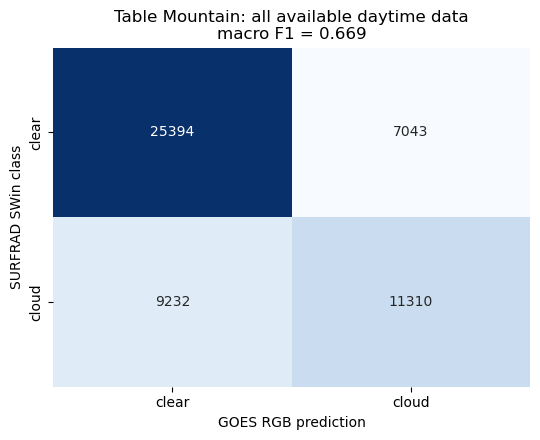

In [3]:
truth, prediction = compare.sw_cloud_binary, compare.rgb_cloud_binary
cm = confusion_matrix(truth, prediction, labels=[0, 1])
report = classification_report(
    truth, prediction, labels=[0, 1], target_names=['clear', 'cloud'],
    output_dict=True, zero_division=0,
)
metrics = pd.DataFrame([{
    'n': len(compare),
    'n_dates': compare.time.dt.normalize().nunique(),
    'accuracy': (truth == prediction).mean(),
    'balanced_accuracy': balanced_accuracy_score(truth, prediction),
    'cohen_kappa': cohen_kappa_score(truth, prediction),
    'macro_f1': f1_score(truth, prediction, average='macro', zero_division=0),
    'weighted_f1': f1_score(truth, prediction, average='weighted', zero_division=0),
    'clear_precision': report['clear']['precision'],
    'clear_recall': report['clear']['recall'],
    'cloud_precision': report['cloud']['precision'],
    'cloud_recall': report['cloud']['recall'],
}])
display(metrics)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
            xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
ax.set(xlabel='GOES RGB prediction', ylabel='SURFRAD SWin class',
       title=f"Table Mountain: all available daytime data\nmacro F1 = {metrics.macro_f1.iloc[0]:.3f}")
fig.tight_layout()
fig.savefig(OUT / 'boulder_binary_confusion_all_available.png', dpi=200)
plt.show()

## 4. Skill by UTC hour

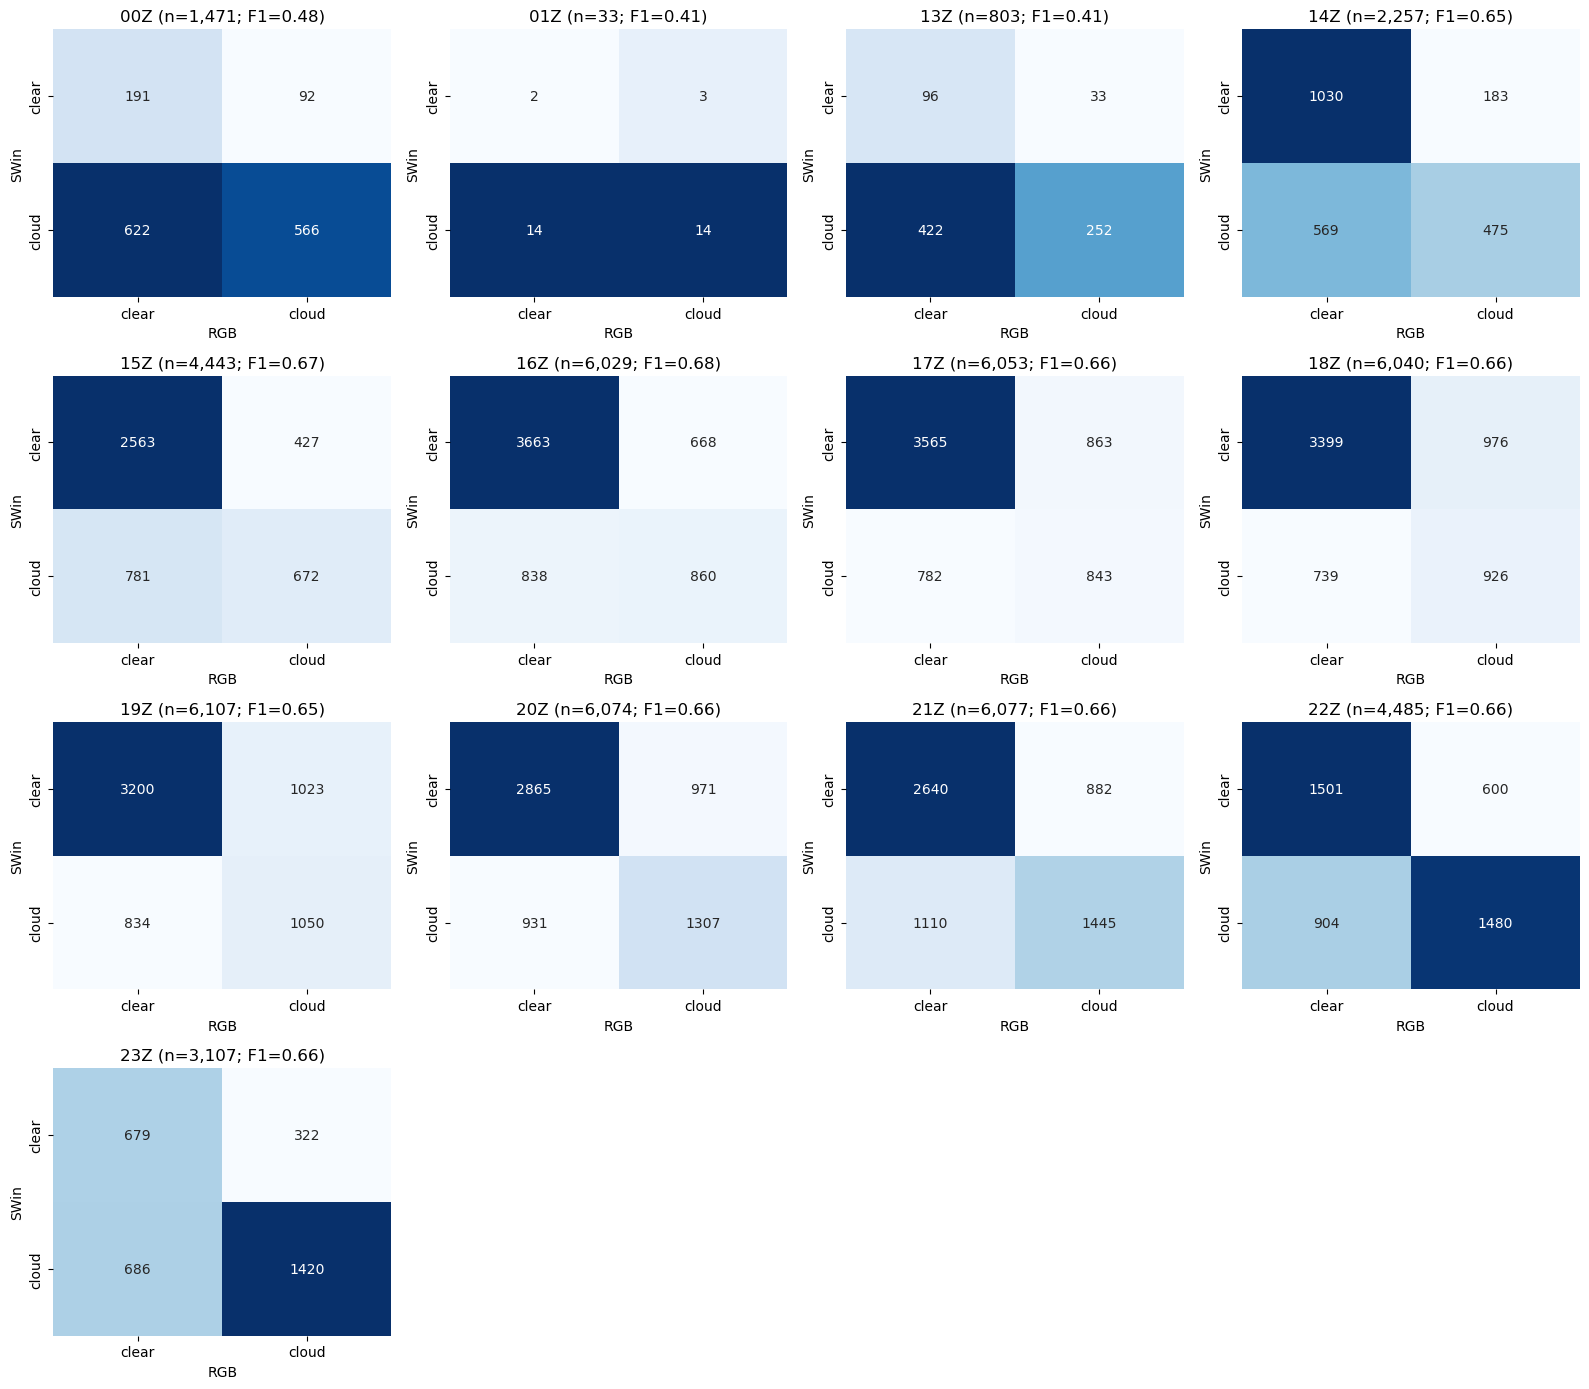

,utc_hour,n,macro_f1,accuracy
0,0,1471,0.480879,0.514616
1,1,33,0.406349,0.484848
2,13,803,0.411151,0.433375
3,14,2257,0.645371,0.666814
4,15,4443,0.667965,0.728112
5,16,6029,0.681326,0.750207
6,17,6053,0.659345,0.728234
7,18,6040,0.658874,0.716060
8,19,6107,0.652902,0.695923
9,20,6074,0.664808,0.686862


In [4]:
compare['utc_hour'] = compare.time.dt.hour
hourly_metrics = []
hours = sorted(compare.utc_hour.unique())
ncols = 4
nrows = int(np.ceil(len(hours) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3.5*nrows))
axes = np.atleast_1d(axes).ravel()
for ax, hour in zip(axes, hours):
    group = compare.loc[compare.utc_hour == hour]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1])
    score = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary,
                     average='macro', zero_division=0)
    hourly_metrics.append({
        'utc_hour': hour, 'n': len(group), 'macro_f1': score,
        'accuracy': (group.sw_cloud_binary == group.rgb_cloud_binary).mean(),
    })
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
    ax.set_title(f'{hour:02d}Z (n={len(group):,}; F1={score:.2f})')
    ax.set_xlabel('RGB'); ax.set_ylabel('SWin')
for ax in axes[len(hours):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / 'boulder_binary_confusion_by_utc_hour.png', dpi=200)
plt.show()
hourly_metrics = pd.DataFrame(hourly_metrics)
display(hourly_metrics)

## 5. Skill by month

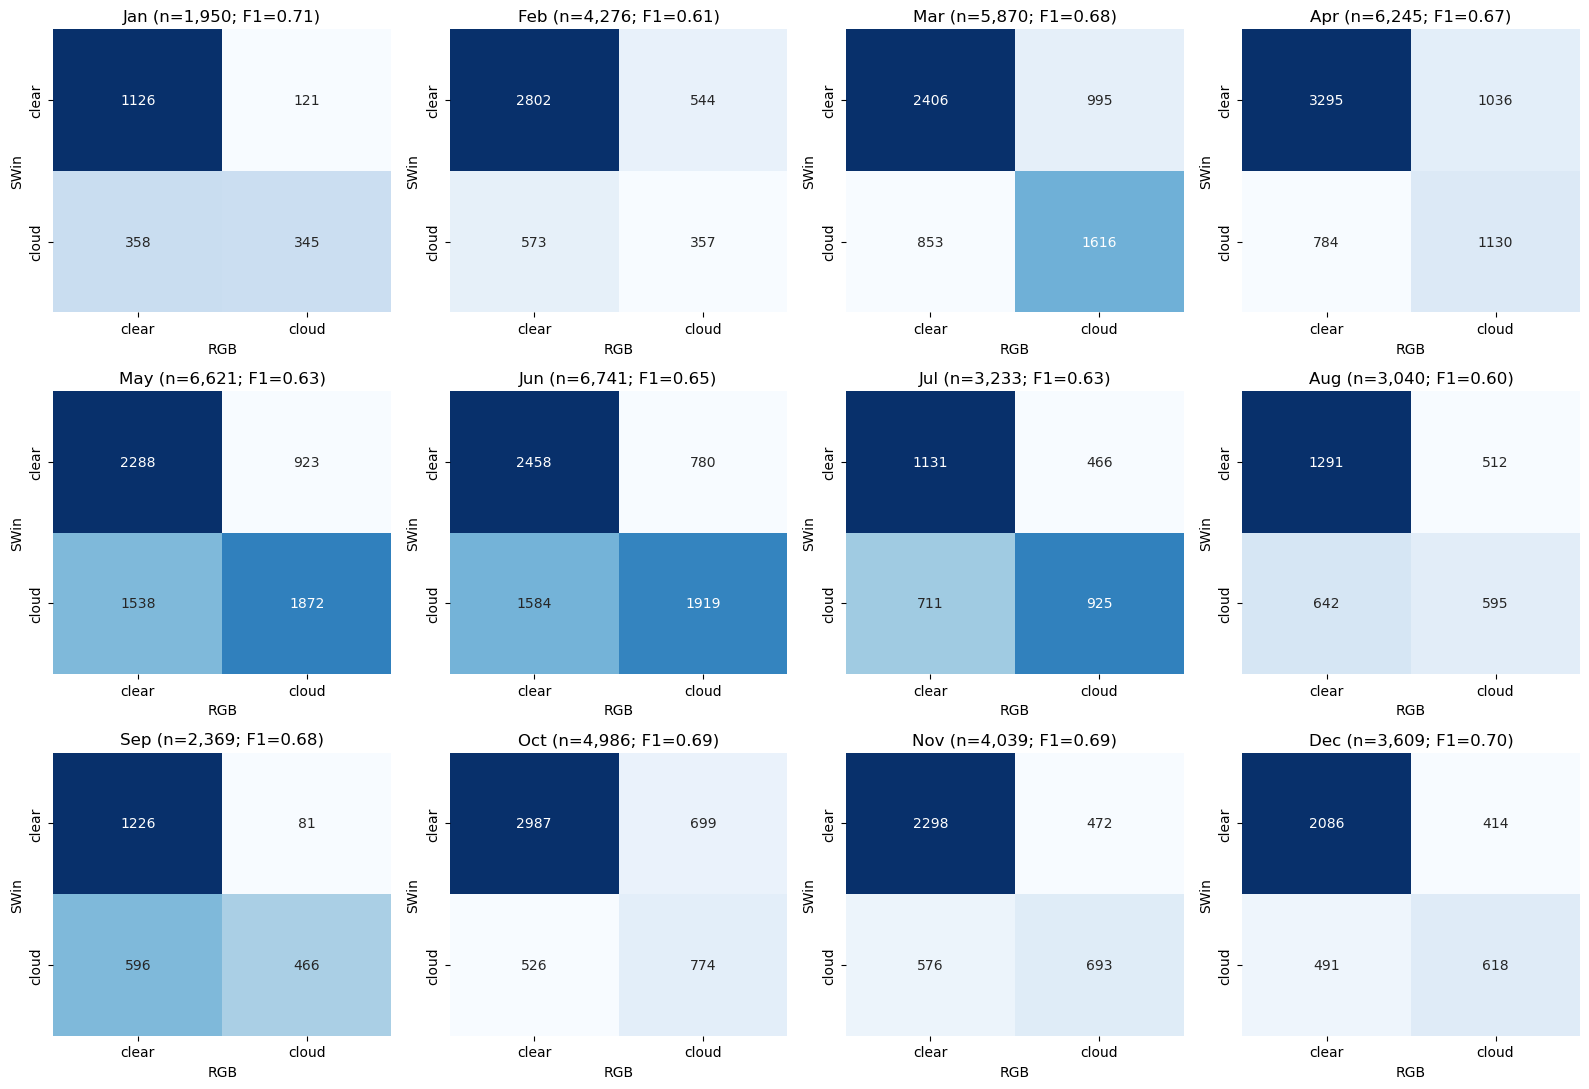

,month,month_name,n,macro_f1,accuracy
0,1,Jan,1950,0.707427,0.754359
1,2,Feb,4276,0.611878,0.738775
2,3,Mar,5870,0.679371,0.685179
3,4,Apr,6245,0.668756,0.708567
4,5,May,6621,0.626831,0.628304
5,6,Jun,6741,0.647054,0.649310
6,7,Jul,3233,0.634458,0.635942
7,8,Aug,3040,0.599396,0.620395
8,9,Sep,2369,0.681439,0.714225
9,10,Oct,4986,0.694039,0.754312


In [5]:
compare['month'] = compare.time.dt.month
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly_metrics = []
fig, axes = plt.subplots(3, 4, figsize=(16, 11))
for month, ax in enumerate(axes.ravel(), start=1):
    group = compare.loc[compare.month == month]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1])
    score = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary,
                     average='macro', zero_division=0) if len(group) else np.nan
    monthly_metrics.append({
        'month': month, 'month_name': month_names[month-1], 'n': len(group),
        'macro_f1': score,
        'accuracy': (group.sw_cloud_binary == group.rgb_cloud_binary).mean() if len(group) else np.nan,
    })
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
    ax.set_title(f'{month_names[month-1]} (n={len(group):,}; F1={score:.2f})')
    ax.set_xlabel('RGB'); ax.set_ylabel('SWin')
fig.tight_layout()
fig.savefig(OUT / 'boulder_binary_confusion_by_month.png', dpi=200)
plt.show()
monthly_metrics = pd.DataFrame(monthly_metrics)
display(monthly_metrics)

## 6. Skill by air-temperature bin

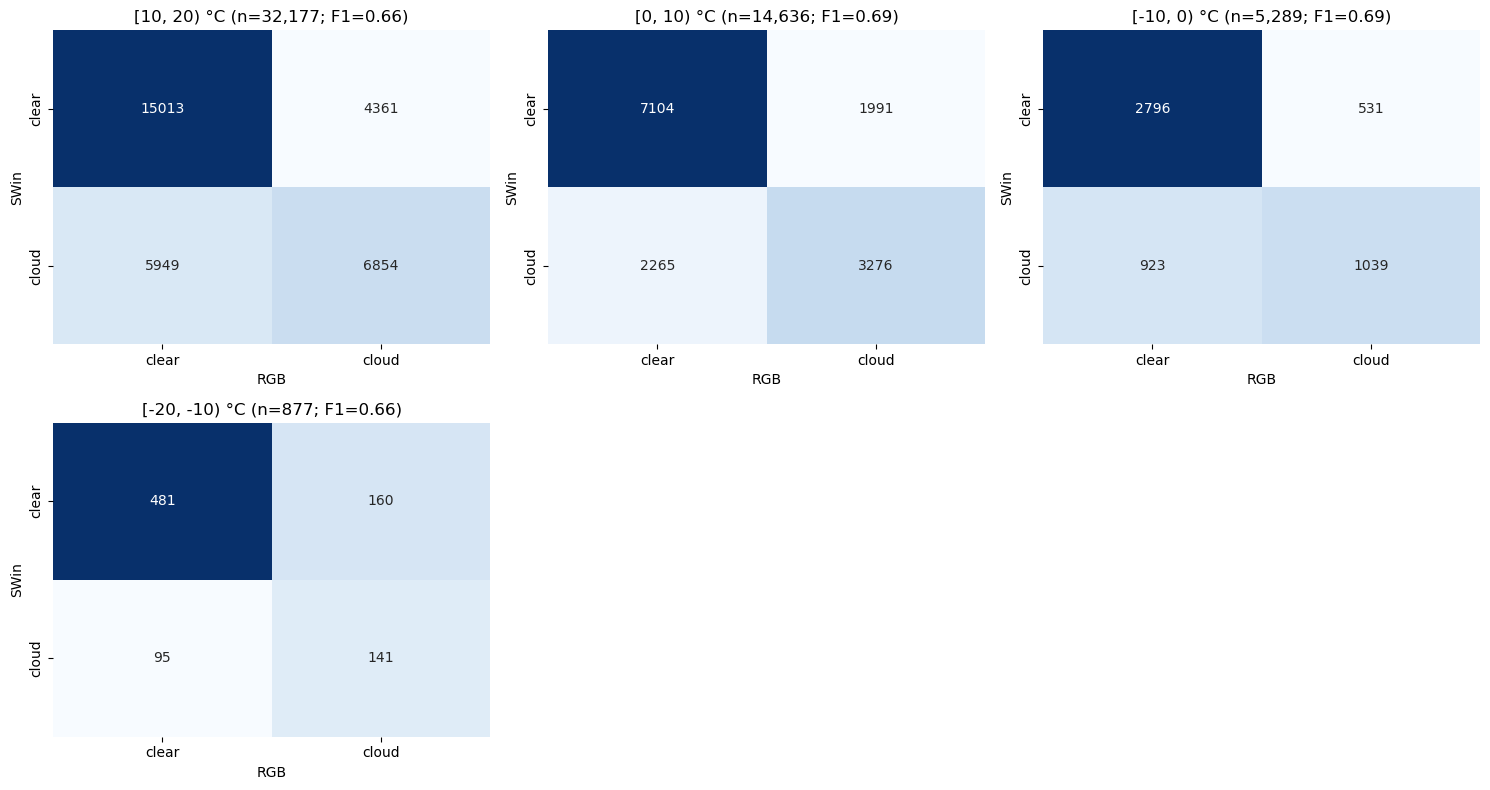

,temp_bin,n,macro_f1,accuracy
0,"[10, 20)",32177,0.657568,0.679585
1,"[0, 10)",14636,0.687858,0.709210
2,"[-10, 0)",5289,0.690989,0.725090
3,"[-20, -10)",877,0.657804,0.709236


In [6]:
tempbin_metrics = []
bins = list(dict.fromkeys(compare.temp_bin))
ncols = 3
nrows = int(np.ceil(len(bins) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = np.atleast_1d(axes).ravel()
for label, ax in zip(bins, axes):
    group = compare.loc[compare.temp_bin == label]
    group_cm = confusion_matrix(group.sw_cloud_binary, group.rgb_cloud_binary, labels=[0, 1])
    score = f1_score(group.sw_cloud_binary, group.rgb_cloud_binary,
                     average='macro', zero_division=0)
    tempbin_metrics.append({
        'temp_bin': label, 'n': len(group), 'macro_f1': score,
        'accuracy': (group.sw_cloud_binary == group.rgb_cloud_binary).mean(),
    })
    sns.heatmap(group_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['clear', 'cloud'], yticklabels=['clear', 'cloud'])
    ax.set_title(f'{label} °C (n={len(group):,}; F1={score:.2f})')
    ax.set_xlabel('RGB'); ax.set_ylabel('SWin')
for ax in axes[len(bins):]:
    ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / 'boulder_binary_confusion_by_temperature_bin.png', dpi=200)
plt.show()
tempbin_metrics = pd.DataFrame(tempbin_metrics)
display(tempbin_metrics)

## 7. Mammoth versus Boulder RGB histograms by ERA5-Land temperature bin

These panels use the common 17–23 UTC evaluation window. Color denotes the
SWin truth class; line style denotes the evaluation site. Successful threshold
transfer requires comparable clear/cloud feature distributions at both sites.

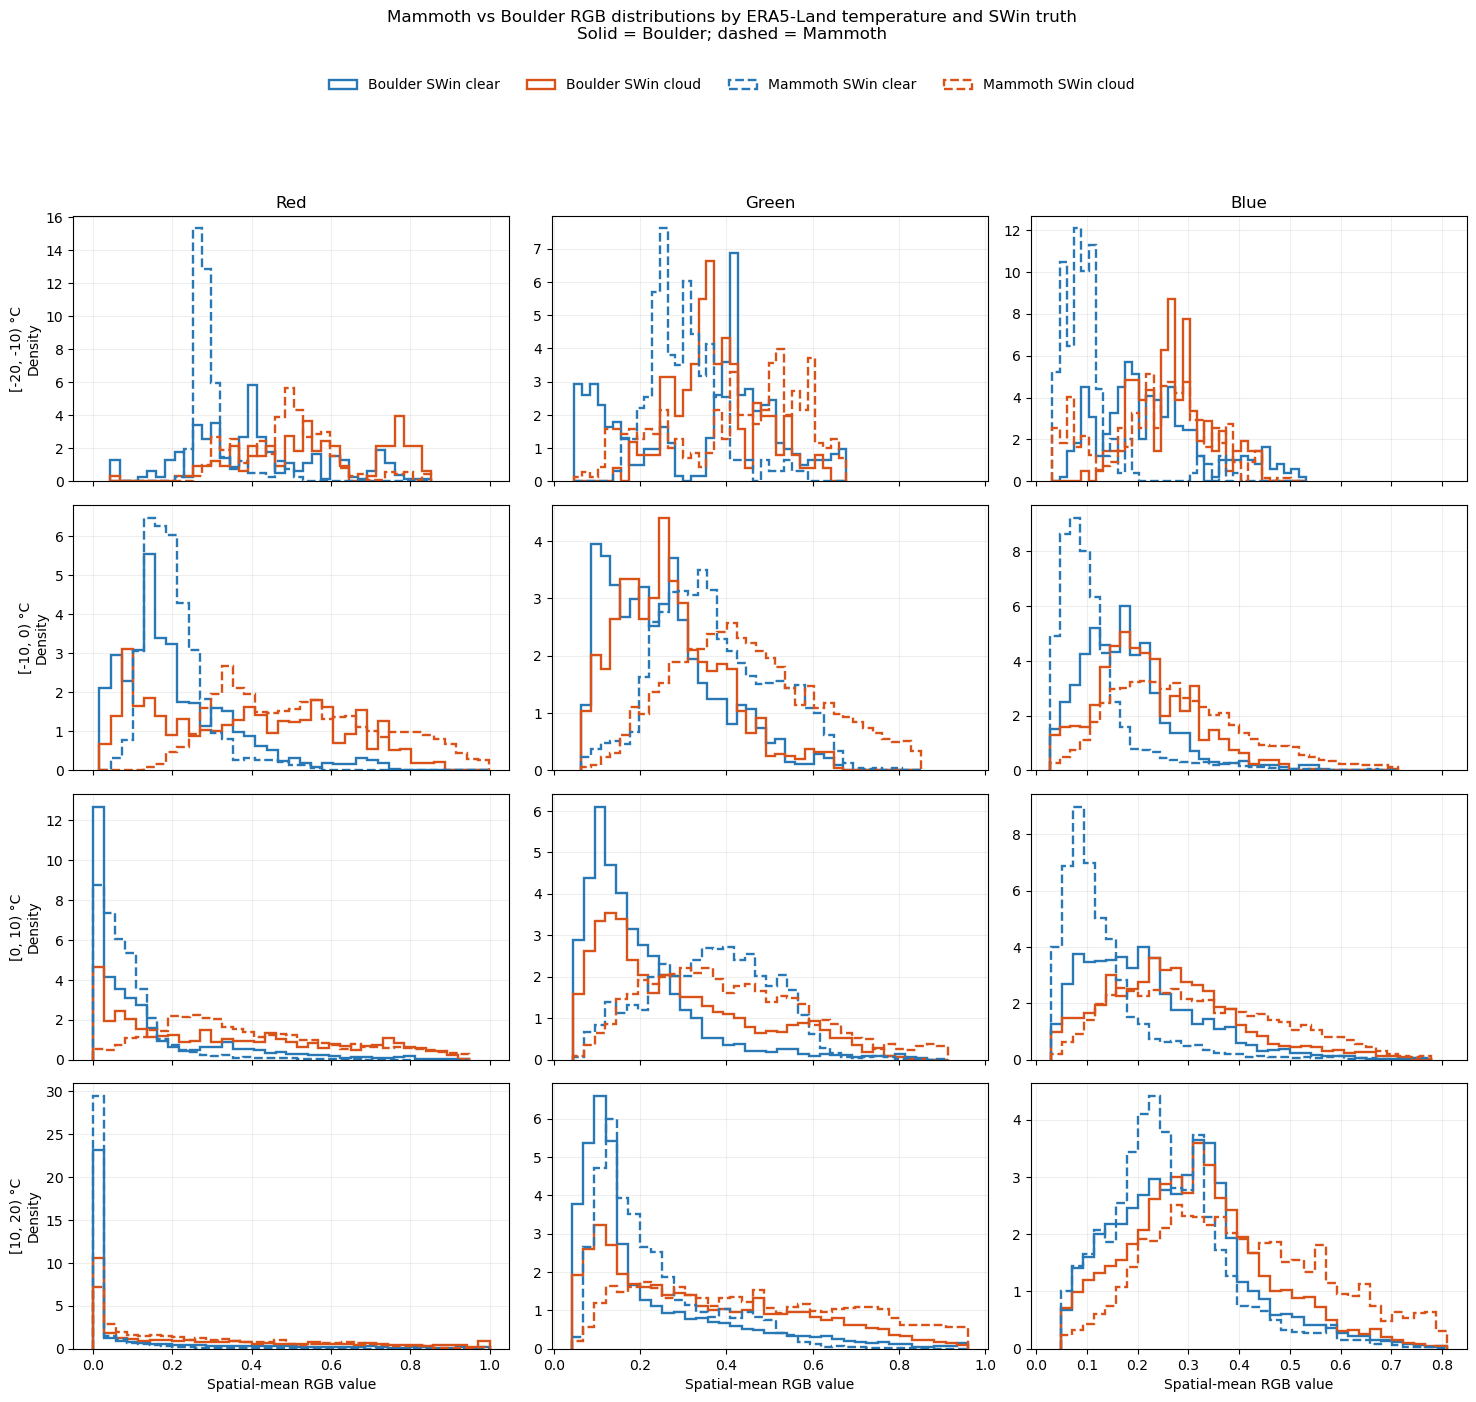

,site,temp_bin,red_cloud_minus_clear,green_cloud_minus_clear,blue_cloud_minus_clear
0,Boulder,"[-10, 0)",0.174594,0.019517,0.039715
1,Boulder,"[-20, -10)",0.161224,0.046568,0.033993
2,Boulder,"[0, 10)",0.200522,0.090436,0.058891
3,Boulder,"[10, 20)",0.176425,0.123320,0.032957
4,Mammoth,"[-10, 0)",0.329374,0.077069,0.170395
5,Mammoth,"[-20, -10)",0.192763,0.112961,0.131413
6,Mammoth,"[0, 10)",0.315652,0.052089,0.199657
7,Mammoth,"[10, 20)",0.241267,0.235930,0.147045


In [7]:
MAMMOTH_OUT = ANALYSIS / 'output_13_mammoth_domain_cloud_fraction'
mammoth_rgb = pd.read_csv(
    MAMMOTH_OUT / 'mammoth_cues_rgb_binary_all_available.csv',
    parse_dates=['time'],
)
mammoth_sw = pd.read_csv(
    MAMMOTH_OUT / 'mammoth_cues_sw_binary_all_available.csv',
    parse_dates=['time'],
)
mammoth_hist = mammoth_rgb[[
    'time', 'red', 'green', 'blue', 'era5_temp_c', 'temp_bin'
]].merge(
    mammoth_sw[['time', 'sw_cloud_binary']],
    on='time', how='inner', validate='one_to_one',
)
mammoth_hist = mammoth_hist.loc[mammoth_hist.time.dt.hour.between(17, 23)].copy()
mammoth_hist['site'] = 'Mammoth'

boulder_hist = compare.loc[compare.time.dt.hour.between(17, 23), [
    'time', 'red', 'green', 'blue', 'era5_temp_c', 'temp_bin', 'sw_cloud_binary'
]].copy()
boulder_hist['site'] = 'Boulder'

hist_data = pd.concat([mammoth_hist, boulder_hist], ignore_index=True)
bin_order = ['[-20, -10)', '[-10, 0)', '[0, 10)', '[10, 20)']
band_order = ['red', 'green', 'blue']
class_style = {
    0: {'color': '#2878B5', 'label': 'SWin clear'},
    1: {'color': '#D95319', 'label': 'SWin cloud'},
}
site_style = {'Boulder': '-', 'Mammoth': '--'}

fig, axes = plt.subplots(4, 3, figsize=(15, 14), sharex='col', sharey=False)
for row, temp_bin in enumerate(bin_order):
    for col, band in enumerate(band_order):
        ax = axes[row, col]
        panel = hist_data.loc[hist_data.temp_bin == temp_bin]
        finite = panel[band].replace([np.inf, -np.inf], np.nan).dropna()
        if finite.empty:
            ax.set_visible(False)
            continue
        lo, hi = np.nanpercentile(finite, [0.5, 99.5])
        edges = np.linspace(lo, hi, 36)
        for site in ['Boulder', 'Mammoth']:
            for truth_class in [0, 1]:
                values = panel.loc[
                    (panel.site == site) & (panel.sw_cloud_binary == truth_class), band
                ].dropna()
                if len(values):
                    ax.hist(
                        values, bins=edges, density=True, histtype='step', linewidth=1.7,
                        color=class_style[truth_class]['color'],
                        linestyle=site_style[site],
                        label=f"{site} {class_style[truth_class]['label']}",
                    )
        if row == 0:
            ax.set_title(band.capitalize())
        if col == 0:
            ax.set_ylabel(f'{temp_bin} °C\nDensity')
        if row == len(bin_order) - 1:
            ax.set_xlabel('Spatial-mean RGB value')
        ax.grid(alpha=.2)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='upper center', bbox_to_anchor=(.5, .958),
    ncol=4, frameon=False,
)
fig.suptitle(
    'Mammoth vs Boulder RGB distributions by ERA5-Land temperature and SWin truth\n'
    'Solid = Boulder; dashed = Mammoth',
    y=.998,
)
fig.tight_layout(rect=(0, 0, 1, .91))
fig.savefig(OUT / 'boulder_vs_mammoth_rgb_histograms_by_temp_bin.png', dpi=220)
plt.show()

separation_rows = []
for (site, temp_bin), group in hist_data.groupby(['site', 'temp_bin']):
    means = group.groupby('sw_cloud_binary')[band_order].mean()
    if {0, 1}.issubset(means.index):
        separation_rows.append({
            'site': site, 'temp_bin': temp_bin,
            **{f'{band}_cloud_minus_clear': means.loc[1, band] - means.loc[0, band]
               for band in band_order},
        })
rgb_separation = pd.DataFrame(separation_rows)
display(rgb_separation)

## 8. Diagnostic time series for the most complete week

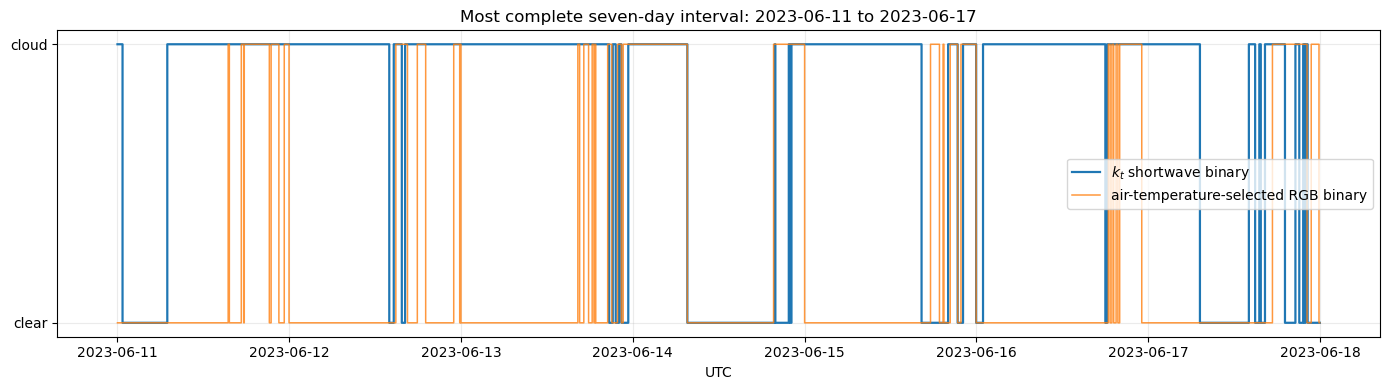

In [8]:
daily_counts = compare.set_index('time').resample('D').size()
weekly_counts = daily_counts.rolling(7, min_periods=1).sum()
week_end = weekly_counts.idxmax()
week_start = week_end - pd.Timedelta(days=6)
week = compare.loc[compare.time.between(week_start, week_end + pd.Timedelta(days=1))]

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(week.time, week.sw_cloud_binary, where='mid',
        label='$k_t$ shortwave binary', lw=1.6)
ax.step(week.time, week.rgb_cloud_binary, where='mid',
        label='air-temperature-selected RGB binary', lw=1.1, alpha=.8)
ax.set_yticks([0, 1], ['clear', 'cloud'])
ax.set_xlabel('UTC'); ax.grid(alpha=.25); ax.legend()
ax.set_title(f'Most complete seven-day interval: {week_start:%Y-%m-%d} to {week_end:%Y-%m-%d}')
fig.tight_layout()
fig.savefig(OUT / 'boulder_binary_most_complete_week.png', dpi=200)
plt.show()

## 9. Export matched data and metrics

In [9]:
compare.to_csv(OUT / 'boulder_binary_comparison_all_available.csv', index=False)
metrics.to_csv(OUT / 'boulder_binary_metrics_all_available.csv', index=False)
hourly_metrics.to_csv(OUT / 'boulder_binary_metrics_by_utc_hour.csv', index=False)
monthly_metrics.to_csv(OUT / 'boulder_binary_metrics_by_month.csv', index=False)
tempbin_metrics.to_csv(OUT / 'boulder_binary_metrics_by_temperature_bin.csv', index=False)
rgb_separation.to_csv(OUT / 'boulder_vs_mammoth_rgb_separation_by_temperature_bin.csv', index=False)
print('Saved comparison outputs to', OUT.resolve())

Saved comparison outputs to /glade/u/home/cdalden/goes_work/analysis/output_13b_boulder_domain_cloud_binary


## 10. Seasonal transfer skill across all three evaluation sites

For a consistent comparison, all sites are restricted to the common 17–23 UTC
window. Each season has a macro-F1 column (circles) and an accuracy column
(X marks); color identifies the evaluation site.

,site,season,n,n_dates,macro_f1_percent,accuracy_percent
0,"Mammoth/CUES, CA",Winter,9915,206,84.904851,85.829551
1,"Mammoth/CUES, CA",Spring,11989,188,90.131421,90.966719
2,"Mammoth/CUES, CA",Summer,6817,185,80.380599,80.504621
3,"Mammoth/CUES, CA",Fall,6871,190,78.045078,78.387425
4,"Table Mountain, CO",Winter,8011,148,68.229928,75.446261
5,"Table Mountain, CO",Spring,12736,184,65.749143,66.308103
6,"Table Mountain, CO",Summer,8639,122,64.281214,64.417178
7,"Table Mountain, CO",Fall,8557,148,68.207311,73.226598
8,"Senator Beck, CO",Winter,1036,236,89.613215,90.444015
9,"Senator Beck, CO",Spring,1143,239,78.824670,81.189851


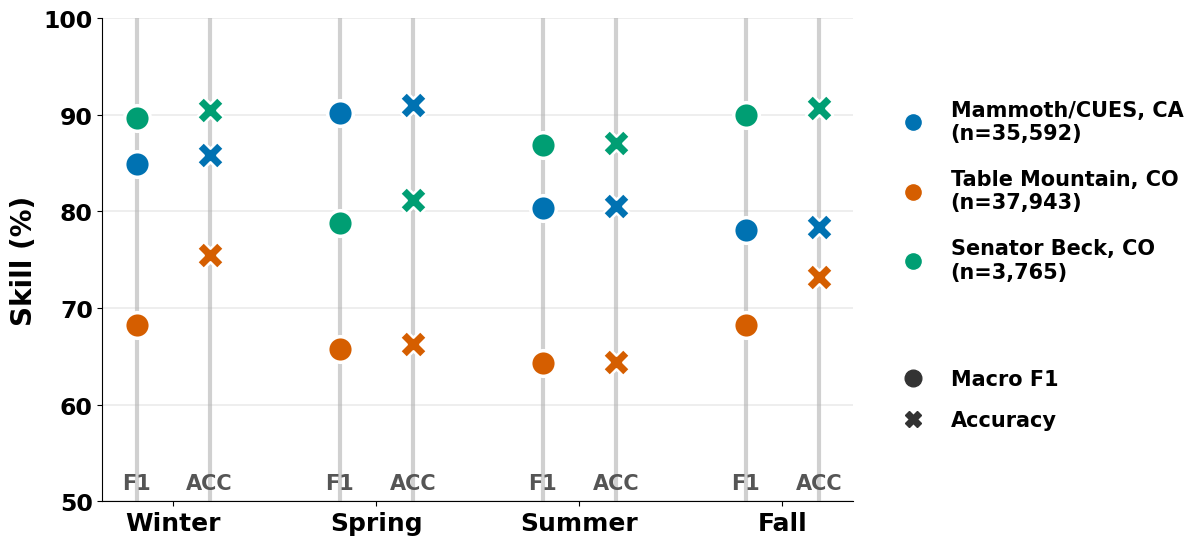

In [40]:
site_files = {
    'Mammoth/CUES, CA': ANALYSIS / 'output_13_mammoth_domain_cloud_fraction'
               / 'mammoth_cues_binary_comparison_all_available.csv',
    'Table Mountain, CO': OUT / 'boulder_binary_comparison_all_available.csv',
    'Senator Beck, CO': ANALYSIS / 'output_13c_senator_beck_domain_cloud_binary'
                    / 'senator_beck_binary_comparison_all_available.csv',
}
season_for_month = {
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall',
}
season_order = ['Winter', 'Spring', 'Summer', 'Fall']
site_order = ['Mammoth/CUES, CA', 'Table Mountain, CO', 'Senator Beck, CO']

seasonal_rows = []
for site, path in site_files.items():
    site_data = pd.read_csv(path, parse_dates=['time'])
    site_data = site_data.loc[site_data.time.dt.hour.between(17, 23)].copy()
    site_data['season'] = site_data.time.dt.month.map(season_for_month)
    for season in season_order:
        group = site_data.loc[site_data.season == season]
        seasonal_rows.append({
            'site': site,
            'season': season,
            'n': len(group),
            'n_dates': group.time.dt.normalize().nunique(),
            'macro_f1_percent': 100 * f1_score(
                group.sw_cloud_binary, group.rgb_cloud_binary,
                average='macro', zero_division=0,
            ),
            'accuracy_percent': 100 * (
                group.sw_cloud_binary == group.rgb_cloud_binary
            ).mean(),
        })
seasonal_skill = pd.DataFrame(seasonal_rows)
display(seasonal_skill)

site_colors = {
    'Mammoth/CUES, CA': '#0072B2',
    'Table Mountain, CO': '#D55E00',
    'Senator Beck, CO': '#009E73',
}
with plt.rc_context({
    'font.size': 18,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 20,
    'xtick.labelsize': 18,
    'ytick.labelsize': 17,
}):
    fig, ax = plt.subplots(figsize=(13, 5.8))
    season_x = np.arange(len(season_order))
    f1_x = season_x - 0.18
    accuracy_x = season_x + 0.18

    for x_left, x_right in zip(f1_x, accuracy_x):
        ax.axvline(x_left, color='#D0D0D0', linewidth=3, zorder=0)
        ax.axvline(x_right, color='#D0D0D0', linewidth=3, zorder=0)

    for site in site_order:
        site_panel = (
            seasonal_skill.loc[seasonal_skill.site == site]
            .set_index('season').reindex(season_order)
        )
        ax.scatter(
            f1_x, site_panel.macro_f1_percent,
            s=340, marker='o', color=site_colors[site],
            edgecolor='white', linewidth=2.5, zorder=3,
        )
        ax.scatter(
            accuracy_x, site_panel.accuracy_percent,
            s=380, marker='X', color=site_colors[site],
            edgecolor='white', linewidth=1.8, zorder=3,
        )

    ax.set_xticks(season_x, season_order)
    ax.set_ylabel('Skill (%)')
    ax.set_ylim(50, 100)
    ax.set_yticks(np.arange(50, 101, 10))
    ax.grid(axis='y', alpha=.25, linewidth=1.2)
    ax.spines[['top', 'right']].set_visible(False)
    for label in [*ax.get_xticklabels(), *ax.get_yticklabels()]:
        label.set_fontweight('bold')

    for center in season_x:
        ax.text(center - 0.18, 50.9, 'F1', ha='center', va='bottom',
                fontsize=15, fontweight='bold', color='#555555')
        ax.text(center + 0.18, 50.9, 'ACC', ha='center', va='bottom',
                fontsize=15, fontweight='bold', color='#555555')

    from matplotlib.lines import Line2D
    site_handles = [
        Line2D([0], [0], marker='o', linestyle='none', markersize=13,
               markerfacecolor=site_colors[site], markeredgecolor='white',
               label=f"{site}\n(n={seasonal_skill.loc[seasonal_skill.site == site, 'n'].sum():,})")
        for site in site_order
    ]
    metric_handles = [
        Line2D([0], [0], marker='o', linestyle='none', markersize=12,
               color='#333333', label='Macro F1'),
        Line2D([0], [0], marker='X', linestyle='none', markersize=12,
               color='#333333', label='Accuracy'),
    ]
    site_legend = fig.legend(
        handles=site_handles,
        loc='center left', bbox_to_anchor=(.685, .64),
        ncol=1, frameon=False, fontsize=15,
        labelspacing=1.25, handletextpad=.8,
    )
    for text in site_legend.get_texts():
        text.set_fontweight('bold')
    metric_legend = fig.legend(
        handles=metric_handles,
        loc='center left', bbox_to_anchor=(.685, .28),
        ncol=1, frameon=False, fontsize=15,
        labelspacing=1.0, handletextpad=.8,
    )
    for text in metric_legend.get_texts():
        text.set_fontweight('bold')
    fig.tight_layout(rect=(0, 0, .69, 1))
    fig.savefig(OUT / 'three_site_seasonal_skill_lollipop.png',
                dpi=300)
    plt.show()